In [4]:
# ==============================
# 5-Fold Video Data Pipeline  (Leakage-Safe Version)
# ==============================
import cv2
from pathlib import Path
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import KFold
import os

# -----------------------------
# Paths and Parameters
# -----------------------------
dataset_root = Path("Hockey Fight Vidoes")
frames_root = Path("HockeyFrames")
frames_root.mkdir(exist_ok=True, parents=True)

classes = ["Fight", "NoFight"]
K = 5  # Number of folds

# -----------------------------
# Step 1: Collect all videos and labels
# -----------------------------
all_videos = []
all_labels = []

for class_name in classes:
    class_folder = dataset_root / class_name
    if not class_folder.exists():
        raise ValueError(f"Folder not found: {class_folder}")
    for video_file in class_folder.glob("*.*"):  # all video extensions
        all_videos.append(video_file)
        all_labels.append(class_name)

print(f"Total videos found: {len(all_videos)}")

# -----------------------------
# Step 2: Extract frames from all videos
# -----------------------------
def extract_frames(video_path, save_dir):
    save_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_filename = save_dir / f"{video_path.stem}_frame{frame_count:04d}.jpg"
        cv2.imwrite(str(frame_filename), frame)
        frame_count += 1
    cap.release()

print("Extracting frames from all videos...")
for video in tqdm(all_videos):
    video_folder = frames_root / video.stem
    extract_frames(video, video_folder)

# -----------------------------
# Step 3: K-Fold splitting and CSV creation (LEAKAGE-SAFE)
# -----------------------------
kf = KFold(n_splits=K, shuffle=True, random_state=42)

for fold_idx, (train_indices, val_indices) in enumerate(kf.split(all_videos), 1):
    print(f"\nProcessing Fold {fold_idx}...")
    
    # Split videos and labels
    train_videos = [all_videos[i] for i in train_indices]
    val_videos   = [all_videos[i] for i in val_indices]
    train_labels = [all_labels[i] for i in train_indices]
    val_labels   = [all_labels[i] for i in val_indices]
    
    # -----------------------------------------
    # Leakage-safe CSV creation
    # -----------------------------------------
    def create_csv_leak_safe(video_list, label_list, csv_path):
        rows = []
        for video_path, label in zip(video_list, label_list):
            video_id = video_path.stem  # e.g., fight1
            frame_folder = frames_root / video_id

            for frame_file in frame_folder.glob("*.jpg"):
                rows.append([
                    str(frame_file),   # frame path
                    label,             # class label
                    video_id           # added for video-level evaluation
                ])

        df = pd.DataFrame(rows, columns=["frame", "class", "video_id"])
        df.to_csv(csv_path, index=False)
    
    # CSV paths
    train_csv = frames_root / f"train_fold_{fold_idx}.csv"
    val_csv   = frames_root / f"val_fold_{fold_idx}.csv"
    
    # Create CSVs
    create_csv_leak_safe(train_videos, train_labels, train_csv)
    create_csv_leak_safe(val_videos, val_labels, val_csv)
    
    print(f"Fold {fold_idx} CSVs saved: {train_csv.name}, {val_csv.name}")

print("\n✅ 5-Fold pipeline complete!")
print("   All CSV files are leakage-safe and ready for training and validation")


Total videos found: 1000
Extracting frames from all videos...


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:30<00:00, 11.02it/s]



Processing Fold 1...
Fold 1 CSVs saved: train_fold_1.csv, val_fold_1.csv

Processing Fold 2...
Fold 2 CSVs saved: train_fold_2.csv, val_fold_2.csv

Processing Fold 3...
Fold 3 CSVs saved: train_fold_3.csv, val_fold_3.csv

Processing Fold 4...
Fold 4 CSVs saved: train_fold_4.csv, val_fold_4.csv

Processing Fold 5...
Fold 5 CSVs saved: train_fold_5.csv, val_fold_5.csv

✅ 5-Fold pipeline complete!
   All CSV files are leakage-safe and ready for training and validation


In [8]:
# =========================
# Keyframe Extraction Pipeline (FIXED FULL VERSION)
# =========================

import cv2
import time
import numpy as np
from pathlib import Path
from tqdm import tqdm
import pandas as pd
from skimage.filters import threshold_otsu


# =========================
# PATHS
# =========================

frames_root = Path("HockeyFrames")
keyframes_root = Path("HockeyKeyFrames")
np_root = Path("HockeyNumpy")

classes = ["Fight", "NoFight"]
folds = 5

epsilon = 1e-8


# =========================
# MODE
# =========================

VARIANT_NAME = "full"   # full / uniform_sampling / all_frames
UNIFORM_STRIDE = 5


# =========================
# FUNCTIONS (FIXED)
# =========================

def spatial_score(img):
    contrast = np.std(img)
    edges = cv2.Canny(img, 100, 200).mean() / 255.0
    lap = cv2.Laplacian(img, cv2.CV_64F).var()
    return (contrast + edges + lap) / 3.0


def temporal_motion_score(prev, curr):
    return np.mean(np.abs(curr.astype(np.float32) - prev.astype(np.float32)))


def adaptive_score(s, m):
    eps = 1e-6
    ws = s / (s + m + eps)
    wm = m / (s + m + eps)
    return ws * s + wm * m


def uniform_idx(n):
    idx = np.arange(0, n, UNIFORM_STRIDE)
    return np.unique(np.concatenate(([0, n-1], idx)))


def all_idx(n):
    return np.arange(n)


def safe_otsu(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) == 0:
        return 0.5
    if x.max() - x.min() < epsilon:
        return float(x.mean())
    return float(threshold_otsu(x))


# =========================
# MAIN
# =========================

fold_summary = []
overall_start = time.perf_counter()

for fold in range(1, folds + 1):

    print("\n============================================================")
    print(f"Processing Fold {fold}")
    print(f"Variant: {VARIANT_NAME}")
    print("============================================================")

    train_csv = frames_root / f"train_fold_{fold}.csv"
    val_csv   = frames_root / f"val_fold_{fold}.csv"

    if not train_csv.exists():
        print("Missing CSV -> skip fold")
        continue

    splits = {
        "train": pd.read_csv(train_csv),
        "val": pd.read_csv(val_csv)
    }

    train_scores_all = []

    # =========================
    # PHASE 1
    # =========================
    if VARIANT_NAME == "full":

        for split in ["train", "val"]:

            df = splits[split]

            for cls in classes:

                groups = df[df["class"] == cls].groupby(
                    df["frame"].apply(lambda x: Path(x).parent.name)
                )

                for vid, group in tqdm(groups, desc=f"score {split}/{cls}"):

                    frames = sorted(group["frame"].tolist())

                    prev = None
                    s_list, m_list = [], []

                    for i, fp in enumerate(frames):

                        img = cv2.imread(fp, 0)
                        if img is None:
                            s_list.append(0)
                            m_list.append(0)
                            continue

                        img = cv2.resize(img, (224, 224))

                        s_list.append(spatial_score(img))

                        if i == 0:
                            m_list.append(0)
                        else:
                            m_list.append(temporal_motion_score(prev, img))

                        prev = img

                    s_list = np.array(s_list)
                    m_list = np.array(m_list)

                    if s_list.max() > 0:
                        s_list /= s_list.max()
                    if m_list.max() > 0:
                        m_list /= m_list.max()

                    final = adaptive_score(s_list, m_list)

                    if split == "train":
                        train_scores_all.extend(final)

                    df.loc[group.index, "score"] = final


    # =========================
    # PHASE 2 (OTSU)
    # =========================
    thresh = safe_otsu(train_scores_all)
    print(f"✓ Otsu Threshold (TRAIN only): {thresh:.6f}")


    # =========================
    # PHASE 3 (FIX: CREATE ALL DIRS)
    # =========================

    train_frames = train_keep = 0
    val_frames = val_keep = 0

    for split in ["train", "val"]:

        df = splits[split]

        for cls in classes:

            groups = df[df["class"] == cls].groupby(
                df["frame"].apply(lambda x: Path(x).parent.name)
            )

            for vid, group in tqdm(groups, desc=f"keyframe {split}/{cls}"):

                frames = sorted(group["frame"].tolist())
                n = len(frames)

                if n == 0:
                    continue

                # ===== selection =====
                if VARIANT_NAME == "full":
                    scores = group["score"].values
                    idx = np.where(scores >= thresh)[0]
                    idx = np.unique(np.concatenate(([0, n-1], idx)))

                elif VARIANT_NAME == "uniform_sampling":
                    idx = uniform_idx(n)

                else:
                    idx = all_idx(n)

                # ===== STATS =====
                if split == "train":
                    train_frames += n
                    train_keep += len(idx)
                else:
                    val_frames += n
                    val_keep += len(idx)

                # ===== IMPORTANT FIX (NO ERROR) =====
                out_dir = keyframes_root / VARIANT_NAME / split / cls / vid
                out_dir.mkdir(parents=True, exist_ok=True)

                np_dir = np_root / VARIANT_NAME / split / cls
                np_dir.mkdir(parents=True, exist_ok=True)

                arr = []

                for i in idx:
                    img = cv2.imread(frames[i])
                    if img is None:
                        continue

                    cv2.imwrite(str(out_dir / Path(frames[i]).name), img)

                    img = cv2.resize(img, (224, 224)).astype(np.float32) / 255.0
                    arr.append(img)

                np.save(np_dir / f"{vid}.npy", np.array(arr))


    # =========================
    # SUMMARY
    # =========================

    fold_summary.append({
        "fold": fold,
        "variant": VARIANT_NAME,
        "threshold": thresh,
        "train_frames": train_frames,
        "val_frames": val_frames,
        "train_reduction_%": (1 - train_keep/train_frames)*100 if train_frames else 0,
        "val_reduction_%": (1 - val_keep/val_frames)*100 if val_frames else 0,
    })

    print(f"\n✓ Fold {fold} completed.")


# =========================
# FINAL OUTPUT
# =========================

pd.DataFrame(fold_summary).to_csv(np_root / f"{VARIANT_NAME}_summary.csv", index=False)

print("\n✔ DONE ✔ PIPELINE COMPLETED SUCCESSFULLY")


Processing Fold 1
Variant: full


score val/NoFight: 100%|█████████████████████████████████████████████████████████████| 104/104 [00:07<00:00, 14.19it/s]


✓ Otsu Threshold (TRAIN only): 0.747634


keyframe val/NoFight: 100%|██████████████████████████████████████████████████████████| 104/104 [00:20<00:00,  5.11it/s]



✓ Fold 1 completed.

Processing Fold 2
Variant: full


...


✓ Fold 4 completed.

Processing Fold 5
Variant: full


score val/NoFight: 100%|███████████████████████████████████████████████████████████████| 99/99 [00:12<00:00,  7.71it/s]


✓ Otsu Threshold (TRAIN only): 0.753091


keyframe val/NoFight: 100%|████████████████████████████████████████████████████████████| 99/99 [00:46<00:00,  2.15it/s]


✓ Fold 5 completed.

✔ DONE ✔ PIPELINE COMPLETED SUCCESSFULLY


In [9]:
# ============================================================
# CNN Feature Extraction Pipeline
# Robust Path Version
#
# Supports these input layouts automatically:
#
# 1) HockeyNumpy/{variant}/fold_i/train/Fight/video.npz
# 2) HockeyNumpy/{variant}/train/Fight/video.npz
# 3) HockeyNumpy/fold_i/train/Fight/video.npz
# 4) HockeyNumpy/train/Fight/video.npz
#
# Output:
#   HockeyFeatures/{variant}/fold_i/train/Fight/video.npz
#
# IMPORTANT:
#   - CNN architecture is unchanged.
#   - Input frames are loaded from .npz or .npy.
#   - Output features are saved as compressed .npz.
#   - Runtime statistics are saved.
# ============================================================


# =========================
# Imports
# =========================

import time
import platform
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# =========================
# Device
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# =========================
# Paths
# =========================

np_root = Path("HockeyNumpy")
feature_root = Path("HockeyFeatures")

feature_root.mkdir(parents=True, exist_ok=True)


# =========================
# Choose Variant
# =========================
# Change only this line:
#   "full"
#   "uniform_sampling"
#   "all_frames"

VARIANT_NAME = "full"


# =========================
# Parameters
# =========================

classes = ["Fight", "NoFight"]

folds = 5

CNN_FRAME_BATCH_SIZE = 16
OUTPUT_DIM = 512


# =========================
# Validate Variant
# =========================

valid_variants = [
    "full",
    "uniform_sampling",
    "all_frames"
]

if VARIANT_NAME not in valid_variants:
    raise ValueError(
        f"Invalid VARIANT_NAME: {VARIANT_NAME}. "
        f"Choose from: {valid_variants}"
    )


# =========================
# Output Root
# =========================

variant_feature_root = feature_root / VARIANT_NAME
variant_feature_root.mkdir(parents=True, exist_ok=True)


# =========================
# Helper: Find Input Directory
# =========================

def find_input_dir(np_root, variant_name, fold_idx, split_name, cls):
    """
    Automatically find the correct input directory.
    """

    candidates = [

        # Best and recommended layout
        np_root / variant_name / f"fold_{fold_idx}" / split_name / cls,

        # Variant exists but no fold directory
        np_root / variant_name / split_name / cls,

        # Fold exists but no variant directory
        np_root / f"fold_{fold_idx}" / split_name / cls,

        # Old layout: no variant and no fold
        np_root / split_name / cls
    ]

    for path in candidates:

        if path.exists():

            npz_files = list(path.glob("*.npz"))
            npy_files = list(path.glob("*.npy"))

            if len(npz_files) > 0 or len(npy_files) > 0:
                return path

    return None


# =========================
# Dataset
# =========================

class VideoFrameDataset(Dataset):

    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file_path = self.files[idx]

        # ----------------------------------------------------
        # Load frames from .npz or .npy
        # Expected shape:
        #   [num_frames, 224, 224, 3]
        # ----------------------------------------------------

        if file_path.suffix == ".npz":

            with np.load(file_path) as data:

                if "frames" in data.files:
                    frames = data["frames"]

                elif "arr_0" in data.files:
                    frames = data["arr_0"]

                else:
                    raise ValueError(
                        f"No valid frame array found in npz file: {file_path}"
                    )

        elif file_path.suffix == ".npy":

            frames = np.load(file_path)

        else:

            raise ValueError(
                f"Unsupported file format: {file_path}"
            )

        frames = torch.tensor(
            frames,
            dtype=torch.float32
        ).permute(0, 3, 1, 2)

        label = self.labels[idx]
        video_name = file_path.stem

        return frames, label, video_name


# =========================
# CNN Feature Extractor
# =========================

class FeatureCNN(nn.Module):

    def __init__(self, output_dim=512):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),

            nn.Linear(
                128 * 28 * 28,
                output_dim
            ),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        return self.features(x)


# =========================
# Instantiate CNN
# =========================

feature_cnn = FeatureCNN(
    output_dim=OUTPUT_DIM
).to(device)

feature_cnn.eval()


# =========================
# Hardware Info
# =========================

hardware_info_path = (
    variant_feature_root
    / "feature_extraction_hardware_info.txt"
)

with open(hardware_info_path, "w", encoding="utf-8") as f:

    f.write("CNN Feature Extraction Hardware / Software Information\n")
    f.write("======================================================\n")
    f.write(f"Platform: {platform.platform()}\n")
    f.write(f"Processor: {platform.processor()}\n")
    f.write(f"Python: {platform.python_version()}\n")
    f.write(f"PyTorch: {torch.__version__}\n")
    f.write(f"Device: {device}\n")
    f.write(f"CUDA Available: {torch.cuda.is_available()}\n")

    if torch.cuda.is_available():
        f.write(f"CUDA Device Name: {torch.cuda.get_device_name(0)}\n")

    f.write(f"Variant: {VARIANT_NAME}\n")
    f.write(f"CNN frame batch size: {CNN_FRAME_BATCH_SIZE}\n")
    f.write(f"Feature output dimension: {OUTPUT_DIM}\n")
    f.write("Input format: .npz or .npy\n")
    f.write("Output format: compressed .npz\n")


# =========================
# Feature Extraction Loop
# =========================

all_video_stats = []

overall_start = time.perf_counter()

for fold_idx in range(1, folds + 1):

    fold_start = time.perf_counter()

    print("\n============================================================")
    print(f"Processing Fold {fold_idx}")
    print(f"Variant: {VARIANT_NAME}")
    print("============================================================")

    fold_video_stats = []

    for split_name in ["train", "val"]:

        for cls in classes:

            input_dir = find_input_dir(
                np_root=np_root,
                variant_name=VARIANT_NAME,
                fold_idx=fold_idx,
                split_name=split_name,
                cls=cls
            )

            if input_dir is None:
                print(
                    f"Missing directory or no files, skipping: "
                    f"{VARIANT_NAME} | fold_{fold_idx} | {split_name}/{cls}"
                )
                continue

            print(f"Using input directory: {input_dir}")

            files = sorted(
                list(input_dir.glob("*.npz"))
                + list(input_dir.glob("*.npy"))
            )

            if len(files) == 0:
                print(f"No .npz or .npy files found in: {input_dir}")
                continue

            labels = [
                1 if cls == "Fight" else 0
                for _ in files
            ]

            dataset = VideoFrameDataset(
                files=files,
                labels=labels
            )

            loader = DataLoader(
                dataset,
                batch_size=1,
                shuffle=False,
                num_workers=0
            )

            out_dir = (
                variant_feature_root
                / f"fold_{fold_idx}"
                / split_name
                / cls
            )

            out_dir.mkdir(
                parents=True,
                exist_ok=True
            )

            for frames, label, vid_name in tqdm(
                loader,
                desc=f"{VARIANT_NAME} | fold_{fold_idx} | {split_name}/{cls}"
            ):

                # frames shape:
                # [1, num_frames, 3, 224, 224]
                frames = frames.squeeze(0)

                # frames shape:
                # [num_frames, 3, 224, 224]
                num_frames = frames.shape[0]

                if num_frames == 0:
                    print(f"Empty video skipped: {vid_name[0]}")
                    continue

                video_name = vid_name[0]
                label_value = int(label.item())

                feature_start = time.perf_counter()

                all_features = []

                with torch.no_grad():

                    for i in range(
                        0,
                        num_frames,
                        CNN_FRAME_BATCH_SIZE
                    ):

                        batch = frames[
                            i:i + CNN_FRAME_BATCH_SIZE
                        ].to(device)

                        feats = feature_cnn(batch)

                        all_features.append(
                            feats.cpu()
                        )

                features = torch.cat(
                    all_features,
                    dim=0
                ).numpy()

                feature_end = time.perf_counter()

                feature_time_s = feature_end - feature_start

                feature_fps = (
                    num_frames / feature_time_s
                    if feature_time_s > 0 else np.nan
                )

                # ------------------------------------------------
                # Save features as compressed .npz
                # ------------------------------------------------

                output_path = out_dir / f"{video_name}.npz"

                np.savez_compressed(
                    output_path,

                    features=features.astype(np.float32),

                    label=np.array(
                        label_value,
                        dtype=np.int64
                    ),

                    video_name=np.array(
                        video_name
                    ),

                    variant=np.array(
                        VARIANT_NAME
                    ),

                    fold=np.array(
                        fold_idx,
                        dtype=np.int64
                    ),

                    split=np.array(
                        split_name
                    ),

                    class_name=np.array(
                        cls
                    ),

                    num_frames=np.array(
                        num_frames,
                        dtype=np.int64
                    ),

                    feature_dim=np.array(
                        OUTPUT_DIM,
                        dtype=np.int64
                    ),

                    feature_time_s=np.array(
                        feature_time_s,
                        dtype=np.float32
                    ),

                    feature_fps=np.array(
                        feature_fps,
                        dtype=np.float32
                    ),

                    input_file=np.array(
                        str(input_dir / f"{video_name}{files[0].suffix}")
                    )
                )

                row = {
                    "variant": VARIANT_NAME,
                    "fold": fold_idx,
                    "split": split_name,
                    "class": cls,
                    "video": video_name,
                    "label": label_value,

                    "input_directory": str(input_dir),
                    "output_file": str(output_path),

                    "num_frames": num_frames,
                    "feature_dim": OUTPUT_DIM,

                    "feature_time_s": feature_time_s,
                    "feature_fps": feature_fps
                }

                fold_video_stats.append(row)
                all_video_stats.append(row)

    # =========================
    # Save Fold-Level Stats
    # =========================

    fold_end = time.perf_counter()
    fold_total_time_s = fold_end - fold_start

    fold_stats_df = pd.DataFrame(fold_video_stats)

    fold_stats_path = (
        variant_feature_root
        / f"fold_{fold_idx}_feature_video_stats.csv"
    )

    fold_stats_df.to_csv(
        fold_stats_path,
        index=False
    )

    print(f"\nFold {fold_idx} feature stats saved to: {fold_stats_path}")
    print(f"Fold {fold_idx} feature extraction time: {fold_total_time_s:.4f} seconds")


# =========================
# Save Overall Video Stats
# =========================

overall_end = time.perf_counter()
overall_time_s = overall_end - overall_start

video_stats_df = pd.DataFrame(all_video_stats)

video_stats_path = (
    variant_feature_root
    / "feature_extraction_video_stats.csv"
)

video_stats_df.to_csv(
    video_stats_path,
    index=False
)


# =========================
# Summary Statistics
# =========================

summary_rows = []

if len(video_stats_df) > 0:

    for (variant, fold, split), g in video_stats_df.groupby(
        ["variant", "fold", "split"]
    ):

        total_frames = g["num_frames"].sum()
        total_time = g["feature_time_s"].sum()

        effective_fps = (
            total_frames / total_time
            if total_time > 0 else np.nan
        )

        summary_rows.append({
            "variant": variant,
            "fold": fold,
            "split": split,

            "videos": len(g),
            "total_frames": total_frames,
            "avg_frames_per_video": g["num_frames"].mean(),

            "total_feature_time_s": total_time,
            "avg_feature_time_s_per_video": g["feature_time_s"].mean(),

            "effective_feature_fps": effective_fps,
            "avg_feature_fps_per_video": g["feature_fps"].mean()
        })

summary_df = pd.DataFrame(summary_rows)

summary_path = (
    variant_feature_root
    / "feature_extraction_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)


# =========================
# Overall Variant Summary
# =========================

overall_summary_rows = []

if len(video_stats_df) > 0:

    total_frames = video_stats_df["num_frames"].sum()
    total_time = video_stats_df["feature_time_s"].sum()

    effective_fps = (
        total_frames / total_time
        if total_time > 0 else np.nan
    )

    overall_summary_rows.append({
        "variant": VARIANT_NAME,

        "videos": len(video_stats_df),
        "total_frames": total_frames,
        "avg_frames_per_video": video_stats_df["num_frames"].mean(),

        "total_feature_time_s": total_time,
        "avg_feature_time_s_per_video": video_stats_df["feature_time_s"].mean(),

        "effective_feature_fps": effective_fps,
        "avg_feature_fps_per_video": video_stats_df["feature_fps"].mean(),

        "overall_runtime_s": overall_time_s
    })

overall_summary_df = pd.DataFrame(overall_summary_rows)

overall_summary_path = (
    variant_feature_root
    / "feature_extraction_overall_summary.csv"
)

overall_summary_df.to_csv(
    overall_summary_path,
    index=False
)


# =========================
# Print Final Results
# =========================

print("\n============================================================")
print("CNN Feature Extraction Completed")
print("============================================================")

print(f"Variant: {VARIANT_NAME}")
print(f"Total feature extraction runtime: {overall_time_s:.4f} seconds")

print("\nSaved files:")
print(f"  - {video_stats_path}")
print(f"  - {summary_path}")
print(f"  - {overall_summary_path}")
print(f"  - {hardware_info_path}")

print("\nFeature output folder:")
print(f"  - {variant_feature_root}")

print("\nOutput format:")
print("  - compressed .npz only")

print("\nOverall Summary:")
print(overall_summary_df.to_string(index=False))

print("============================================================")

Using device: cuda

Processing Fold 1
Variant: full
Using input directory: HockeyNumpy\full\train\Fight


full | fold_1 | train/Fight: 100%|███████████████████████████████████████████████████| 500/500 [00:24<00:00, 20.82it/s]


Using input directory: HockeyNumpy\full\train\NoFight


full | fold_1 | train/NoFight: 100%|█████████████████████████████████████████████████| 500/500 [00:31<00:00, 15.81it/s]


Using input directory: HockeyNumpy\full\val\Fight


...

Using input directory: HockeyNumpy\full\val\Fight


full | fold_5 | val/Fight: 100%|█████████████████████████████████████████████████████| 500/500 [00:22<00:00, 22.21it/s]


Using input directory: HockeyNumpy\full\val\NoFight


full | fold_5 | val/NoFight: 100%|███████████████████████████████████████████████████| 500/500 [00:26<00:00, 18.53it/s]


Fold 5 feature stats saved to: HockeyFeatures\full\fold_5_feature_video_stats.csv
Fold 5 feature extraction time: 99.0870 seconds

CNN Feature Extraction Completed
Variant: full
Total feature extraction runtime: 501.8459 seconds

Saved files:
  - HockeyFeatures\full\feature_extraction_video_stats.csv
  - HockeyFeatures\full\feature_extraction_summary.csv
  - HockeyFeatures\full\feature_extraction_overall_summary.csv
  - HockeyFeatures\full\feature_extraction_hardware_info.txt

Feature output folder:
  - HockeyFeatures\full

Output format:
  - compressed .npz only

Overall Summary:
variant  videos  total_frames  avg_frames_per_video  total_feature_time_s  avg_feature_time_s_per_video  effective_feature_fps  avg_feature_fps_per_video  overall_runtime_s
   full   10000        270690                27.069            218.043873                      0.021804            1241.447403                 1321.65782          501.84591


In [10]:
# ============================================================
# CELL 1
# GRU Classification Pipeline
# Training + Runtime Measurement + Save Outputs for Plot Cell
#
# IMPORTANT:
#   - GRU architecture is unchanged.
#   - Training settings are unchanged.
#   - Optimizer is unchanged.
#   - Loss function is unchanged.
#   - Epochs are unchanged.
#   - Batch size is unchanged.
#   - GRU inference time is calculated.
#   - Plotting is done in CELL 2.
# ============================================================


# =========================
# Imports
# =========================

import time
import gc
import platform
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)


# =========================
# Device
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# =========================
# Paths
# =========================

feature_root = Path("HockeyFeatures")

# Change only this line for the next run:
#   "full"
#   "uniform_sampling"
#   "all_frames"

VARIANT_NAME = "full"

results_root = Path("GRU_Results") / VARIANT_NAME
results_root.mkdir(parents=True, exist_ok=True)


# =========================
# Training Parameters
# =========================

classes = ["Fight", "NoFight"]

folds = 5

batch_size = 16
epochs = 50
learning_rate = 1e-3

feature_dim = 512
hidden_dim_gru = 128
num_layers = 2
dropout_gru = 0.3


# =========================
# Helper: Find Feature Directory
# =========================

def find_feature_dir(feature_root, variant_name, fold_idx, split_name, cls):
    """
    Automatically find the correct feature directory.
    """

    candidates = [

        # Recommended layout
        feature_root / variant_name / f"fold_{fold_idx}" / split_name / cls,

        # Old layout without variant
        feature_root / f"fold_{fold_idx}" / split_name / cls,

        # Layout without fold
        feature_root / variant_name / split_name / cls,

        # Very old layout
        feature_root / split_name / cls
    ]

    for path in candidates:

        if path.exists():

            npz_files = list(path.glob("*.npz"))
            npy_files = list(path.glob("*.npy"))

            if len(npz_files) > 0 or len(npy_files) > 0:
                return path

    return None


# =========================
# Dataset
# =========================

class FeatureDataset(Dataset):

    def __init__(self, np_files, labels):
        self.np_files = np_files
        self.labels = labels

    def __len__(self):
        return len(self.np_files)

    def __getitem__(self, idx):

        file_path = self.np_files[idx]

        if file_path.suffix == ".npz":

            with np.load(file_path) as data:

                if "features" in data.files:
                    features = data["features"]

                elif "arr_0" in data.files:
                    features = data["arr_0"]

                else:
                    raise ValueError(
                        f"No valid feature array found in npz file: {file_path}"
                    )

        elif file_path.suffix == ".npy":

            features = np.load(file_path)

        else:

            raise ValueError(
                f"Unsupported feature file format: {file_path}"
            )

        features = torch.tensor(
            features,
            dtype=torch.float32
        )

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return features, label


# =========================
# Collate Function
# =========================

def collate_fn(batch):

    sequences, labels = zip(*batch)

    lengths = torch.tensor(
        [len(seq) for seq in sequences]
    )

    padded_seqs = nn.utils.rnn.pad_sequence(
        sequences,
        batch_first=True
    )

    labels = torch.stack(labels)

    return padded_seqs, lengths, labels


# =========================
# GRU Classifier
# =========================

class GRUClassifier(nn.Module):

    def __init__(
        self,
        input_dim=512,
        hidden_dim=128,
        num_layers=2,
        num_classes=2,
        dropout=0.3
    ):

        super().__init__()

        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout
        )

        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x, lengths):

        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_out, _ = self.gru(packed)

        out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out,
            batch_first=True
        )

        last_tokens = torch.stack(
            [
                out[i, lengths[i] - 1, :]
                for i in range(len(lengths))
            ]
        )

        out = self.fc(last_tokens)

        return out


# =========================
# Hardware Info
# =========================

hardware_info_path = results_root / "gru_hardware_info.txt"

with open(hardware_info_path, "w", encoding="utf-8") as f:

    f.write("GRU Training / Inference Hardware Information\n")
    f.write("=============================================\n")
    f.write(f"Platform: {platform.platform()}\n")
    f.write(f"Processor: {platform.processor()}\n")
    f.write(f"Python: {platform.python_version()}\n")
    f.write(f"PyTorch: {torch.__version__}\n")
    f.write(f"Device: {device}\n")
    f.write(f"CUDA Available: {torch.cuda.is_available()}\n")

    if torch.cuda.is_available():
        f.write(f"CUDA Device Name: {torch.cuda.get_device_name(0)}\n")

    f.write(f"Variant: {VARIANT_NAME}\n")
    f.write(f"Batch size: {batch_size}\n")
    f.write(f"Epochs: {epochs}\n")
    f.write(f"Learning rate: {learning_rate}\n")
    f.write(f"Feature dim: {feature_dim}\n")
    f.write(f"GRU hidden dim: {hidden_dim_gru}\n")
    f.write(f"GRU num layers: {num_layers}\n")
    f.write(f"GRU dropout: {dropout_gru}\n")


# =========================
# Cross-Fold Training GRU
# =========================

all_fold_metrics_gru = []
all_fold_rocs = []

fold_final_rows = []
fold_runtime_rows = []
epoch_rows = []

overall_training_start = time.perf_counter()

for fold_idx in range(1, folds + 1):

    print(f"\n=== GRU Fold {fold_idx} ===")

    gc.collect()
    torch.cuda.empty_cache()

    fold_start_time = time.perf_counter()

    train_files = []
    train_labels = []

    val_files = []
    val_labels = []

    for cls_idx, cls in enumerate(classes):

        train_dir = find_feature_dir(
            feature_root=feature_root,
            variant_name=VARIANT_NAME,
            fold_idx=fold_idx,
            split_name="train",
            cls=cls
        )

        val_dir = find_feature_dir(
            feature_root=feature_root,
            variant_name=VARIANT_NAME,
            fold_idx=fold_idx,
            split_name="val",
            cls=cls
        )

        if train_dir is None:
            print(f"Missing train directory for fold {fold_idx}, class {cls}")
            continue

        if val_dir is None:
            print(f"Missing val directory for fold {fold_idx}, class {cls}")
            continue

        cls_train_files = sorted(
            list(train_dir.glob("*.npz"))
            + list(train_dir.glob("*.npy"))
        )

        cls_val_files = sorted(
            list(val_dir.glob("*.npz"))
            + list(val_dir.glob("*.npy"))
        )

        train_files.extend(cls_train_files)
        train_labels.extend(
            [cls_idx] * len(cls_train_files)
        )

        val_files.extend(cls_val_files)
        val_labels.extend(
            [cls_idx] * len(cls_val_files)
        )

    if len(train_files) == 0 or len(val_files) == 0:
        print(f"No feature files found for fold {fold_idx}. Skipping fold.")
        continue

    train_dataset = FeatureDataset(
        train_files,
        train_labels
    )

    val_dataset = FeatureDataset(
        val_files,
        val_labels
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    model = GRUClassifier(
        input_dim=feature_dim,
        hidden_dim=hidden_dim_gru,
        num_layers=num_layers,
        dropout=dropout_gru,
        num_classes=len(classes)
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    epoch_metrics = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_auc": [],
        "val_inference_time_s": [],
        "val_inference_time_per_video_s": []
    }

    for epoch in range(1, epochs + 1):

        # =========================
        # Train
        # =========================

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        train_epoch_start = time.perf_counter()

        for features, lengths, labels in train_loader:

            features = features.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(
                features,
                lengths
            )

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_epoch_end = time.perf_counter()
        train_epoch_time_s = train_epoch_end - train_epoch_start

        train_loss = total_loss / total
        train_acc = correct / total

        # =========================
        # Validation
        # =========================

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        all_preds = []
        all_labels = []
        all_probs = []

        val_inference_time_s = 0.0

        val_epoch_start = time.perf_counter()

        with torch.no_grad():

            for features, lengths, labels in val_loader:

                features = features.to(device)
                lengths = lengths.to(device)
                labels = labels.to(device)

                inference_start = time.perf_counter()

                outputs = model(
                    features,
                    lengths
                )

                probs = nn.functional.softmax(
                    outputs,
                    dim=1
                )[:, 1]

                inference_end = time.perf_counter()

                val_inference_time_s += (
                    inference_end - inference_start
                )

                loss = criterion(
                    outputs,
                    labels
                )

                val_loss += loss.item() * labels.size(0)

                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

                all_preds.extend(
                    preds.cpu().numpy()
                )

                all_labels.extend(
                    labels.cpu().numpy()
                )

                all_probs.extend(
                    probs.cpu().numpy()
                )

        val_epoch_end = time.perf_counter()
        val_epoch_time_s = val_epoch_end - val_epoch_start

        val_loss /= total
        val_acc = correct / total

        val_precision = precision_score(
            all_labels,
            all_preds,
            zero_division=0
        )

        val_recall = recall_score(
            all_labels,
            all_preds,
            zero_division=0
        )

        val_f1 = f1_score(
            all_labels,
            all_preds,
            zero_division=0
        )

        val_auc = roc_auc_score(
            all_labels,
            all_probs
        )

        val_inference_time_per_video_s = (
            val_inference_time_s / total
            if total > 0 else np.nan
        )

        epoch_metrics["train_loss"].append(train_loss)
        epoch_metrics["train_acc"].append(train_acc)
        epoch_metrics["val_loss"].append(val_loss)
        epoch_metrics["val_acc"].append(val_acc)
        epoch_metrics["val_precision"].append(val_precision)
        epoch_metrics["val_recall"].append(val_recall)
        epoch_metrics["val_f1"].append(val_f1)
        epoch_metrics["val_auc"].append(val_auc)
        epoch_metrics["val_inference_time_s"].append(val_inference_time_s)
        epoch_metrics["val_inference_time_per_video_s"].append(
            val_inference_time_per_video_s
        )

        epoch_rows.append({
            "variant": VARIANT_NAME,
            "fold": fold_idx,
            "epoch": epoch,

            "train_loss": train_loss,
            "train_acc": train_acc,

            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_precision": val_precision,
            "val_recall": val_recall,
            "val_f1": val_f1,
            "val_auc": val_auc,

            "train_epoch_time_s": train_epoch_time_s,
            "val_epoch_time_s": val_epoch_time_s,
            "val_inference_time_s": val_inference_time_s,
            "val_inference_time_per_video_s": val_inference_time_per_video_s
        })

        print(
            f"Epoch {epoch}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    all_fold_metrics_gru.append(epoch_metrics)

    fpr, tpr, _ = roc_curve(
        all_labels,
        all_probs
    )

    fold_auc = roc_auc_score(
        all_labels,
        all_probs
    )

    all_fold_rocs.append(
        (fpr, tpr, fold_auc)
    )

    fold_end_time = time.perf_counter()
    fold_total_time_s = fold_end_time - fold_start_time

    final_epoch_idx = -1

    fold_final_rows.append({
        "variant": VARIANT_NAME,
        "fold": fold_idx,

        "val_acc": epoch_metrics["val_acc"][final_epoch_idx],
        "val_precision": epoch_metrics["val_precision"][final_epoch_idx],
        "val_recall": epoch_metrics["val_recall"][final_epoch_idx],
        "val_f1": epoch_metrics["val_f1"][final_epoch_idx],
        "val_auc": epoch_metrics["val_auc"][final_epoch_idx],

        "final_val_inference_time_s": epoch_metrics["val_inference_time_s"][final_epoch_idx],
        "final_val_inference_time_per_video_s": epoch_metrics["val_inference_time_per_video_s"][final_epoch_idx],

        "fold_total_time_s": fold_total_time_s,
        "train_videos": len(train_files),
        "val_videos": len(val_files)
    })

    fold_runtime_rows.append({
        "variant": VARIANT_NAME,
        "fold": fold_idx,

        "fold_total_time_s": fold_total_time_s,
        "final_val_inference_time_s": epoch_metrics["val_inference_time_s"][final_epoch_idx],
        "final_val_inference_time_per_video_s": epoch_metrics["val_inference_time_per_video_s"][final_epoch_idx],

        "train_videos": len(train_files),
        "val_videos": len(val_files)
    })

    print(
        f"Fold {fold_idx} Runtime: "
        f"Total={fold_total_time_s:.4f}s | "
        f"Final GRU Inference={epoch_metrics['val_inference_time_s'][final_epoch_idx]:.6f}s | "
        f"Per Video={epoch_metrics['val_inference_time_per_video_s'][final_epoch_idx]:.6f}s"
    )


overall_training_end = time.perf_counter()
overall_training_time_s = overall_training_end - overall_training_start


# =========================
# Save CSV Results
# =========================

epoch_metrics_df = pd.DataFrame(epoch_rows)
epoch_metrics_path = results_root / "GRU_Epoch_Metrics_All_Folds.csv"
epoch_metrics_df.to_csv(epoch_metrics_path, index=False)

fold_final_df = pd.DataFrame(fold_final_rows)
fold_final_path = results_root / "GRU_Final_Metrics_Per_Fold.csv"
fold_final_df.to_csv(fold_final_path, index=False)

fold_runtime_df = pd.DataFrame(fold_runtime_rows)
fold_runtime_path = results_root / "GRU_Runtime_Per_Fold.csv"
fold_runtime_df.to_csv(fold_runtime_path, index=False)


# =========================
# Save Final Mean/STD Metrics
# =========================

metrics_for_summary = [
    "val_acc",
    "val_precision",
    "val_recall",
    "val_f1",
    "val_auc"
]

metric_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC"
]

final_summary_rows = []

for metric_name, metric_label in zip(
    metrics_for_summary,
    metric_labels
):

    values = [
        fold_metrics[metric_name][-1]
        for fold_metrics in all_fold_metrics_gru
    ]

    final_summary_rows.append({
        "Metric": metric_label,
        "Mean": np.mean(values),
        "Std": np.std(values)
    })

final_summary_df = pd.DataFrame(final_summary_rows)

final_summary_path = results_root / "GRU_Final_Metrics_Mean_STD.csv"
final_summary_df.to_csv(final_summary_path, index=False)


# =========================
# Runtime Summary
# =========================

if len(fold_runtime_df) > 0:

    runtime_summary_df = pd.DataFrame([{
        "variant": VARIANT_NAME,

        "folds": len(fold_runtime_df),

        "mean_fold_total_time_s": fold_runtime_df["fold_total_time_s"].mean(),
        "std_fold_total_time_s": fold_runtime_df["fold_total_time_s"].std(),

        "mean_final_val_inference_time_s": fold_runtime_df["final_val_inference_time_s"].mean(),
        "std_final_val_inference_time_s": fold_runtime_df["final_val_inference_time_s"].std(),

        "mean_final_val_inference_time_per_video_s": fold_runtime_df["final_val_inference_time_per_video_s"].mean(),
        "std_final_val_inference_time_per_video_s": fold_runtime_df["final_val_inference_time_per_video_s"].std(),

        "overall_training_time_s": overall_training_time_s
    }])

else:

    runtime_summary_df = pd.DataFrame()

runtime_summary_path = results_root / "GRU_Runtime_Summary.csv"
runtime_summary_df.to_csv(runtime_summary_path, index=False)


# =========================
# Save ROC Data for CELL 2
# =========================

fpr_points = np.linspace(0, 1, 200)

tprs_interp = []
auc_values = []

for fpr, tpr, fold_auc in all_fold_rocs:

    tpr_interp = np.interp(
        fpr_points,
        fpr,
        tpr
    )

    tpr_interp[0] = 0.0

    tprs_interp.append(tpr_interp)
    auc_values.append(fold_auc)

tprs_interp = np.array(tprs_interp)

mean_tpr = tprs_interp.mean(axis=0)
std_tpr = tprs_interp.std(axis=0)
mean_tpr[-1] = 1.0

mean_auc = np.mean(auc_values)
std_auc = np.std(auc_values)

roc_data_path = results_root / "GRU_ROC_Data.npz"

np.savez_compressed(
    roc_data_path,
    fpr_points=fpr_points,
    mean_tpr=mean_tpr,
    std_tpr=std_tpr,
    mean_auc=np.array(mean_auc, dtype=np.float32),
    std_auc=np.array(std_auc, dtype=np.float32)
)


# =========================
# Print Summary
# =========================

print("=" * 60)
print("GRU TRAINING COMPLETED")
print("=" * 60)

print(f"Variant: {VARIANT_NAME}")
print(f"Overall training time: {overall_training_time_s:.4f} seconds")

print("\nSaved files:")
print(f"Epoch metrics: {epoch_metrics_path}")
print(f"Final fold metrics: {fold_final_path}")
print(f"Final mean/std metrics: {final_summary_path}")
print(f"Runtime per fold: {fold_runtime_path}")
print(f"Runtime summary: {runtime_summary_path}")
print(f"ROC data: {roc_data_path}")
print(f"Hardware info: {hardware_info_path}")

print("=" * 60)

Using device: cuda

=== GRU Fold 1 ===
Epoch 1/50 | Train Loss: 0.6453 | Train Acc: 0.5850 | Val Loss: 0.3703 | Val Acc: 0.8370
Epoch 2/50 | Train Loss: 0.3239 | Train Acc: 0.8730 | Val Loss: 0.4910 | Val Acc: 0.8300
Epoch 3/50 | Train Loss: 0.2426 | Train Acc: 0.9130 | Val Loss: 0.3076 | Val Acc: 0.8750
Epoch 4/50 | Train Loss: 0.2648 | Train Acc: 0.9090 | Val Loss: 0.1803 | Val Acc: 0.9340
Epoch 5/50 | Train Loss: 0.1825 | Train Acc: 0.9350 | Val Loss: 0.1916 | Val Acc: 0.9320
Epoch 6/50 | Train Loss: 0.2323 | Train Acc: 0.9250 | Val Loss: 0.1729 | Val Acc: 0.9410
Epoch 7/50 | Train Loss: 0.1816 | Train Acc: 0.9370 | Val Loss: 0.2912 | Val Acc: 0.8680
Epoch 8/50 | Train Loss: 0.1676 | Train Acc: 0.9450 | Val Loss: 0.2002 | Val Acc: 0.9250
Epoch 9/50 | Train Loss: 0.1920 | Train Acc: 0.9340 | Val Loss: 0.1842 | Val Acc: 0.9430
Epoch 10/50 | Train Loss: 0.1805 | Train Acc: 0.9450 | Val Loss: 0.1289 | Val Acc: 0.9580
Epoch 11/50 | Train Loss: 0.1831 | Train Acc: 0.9410 | Val Loss: 0.118

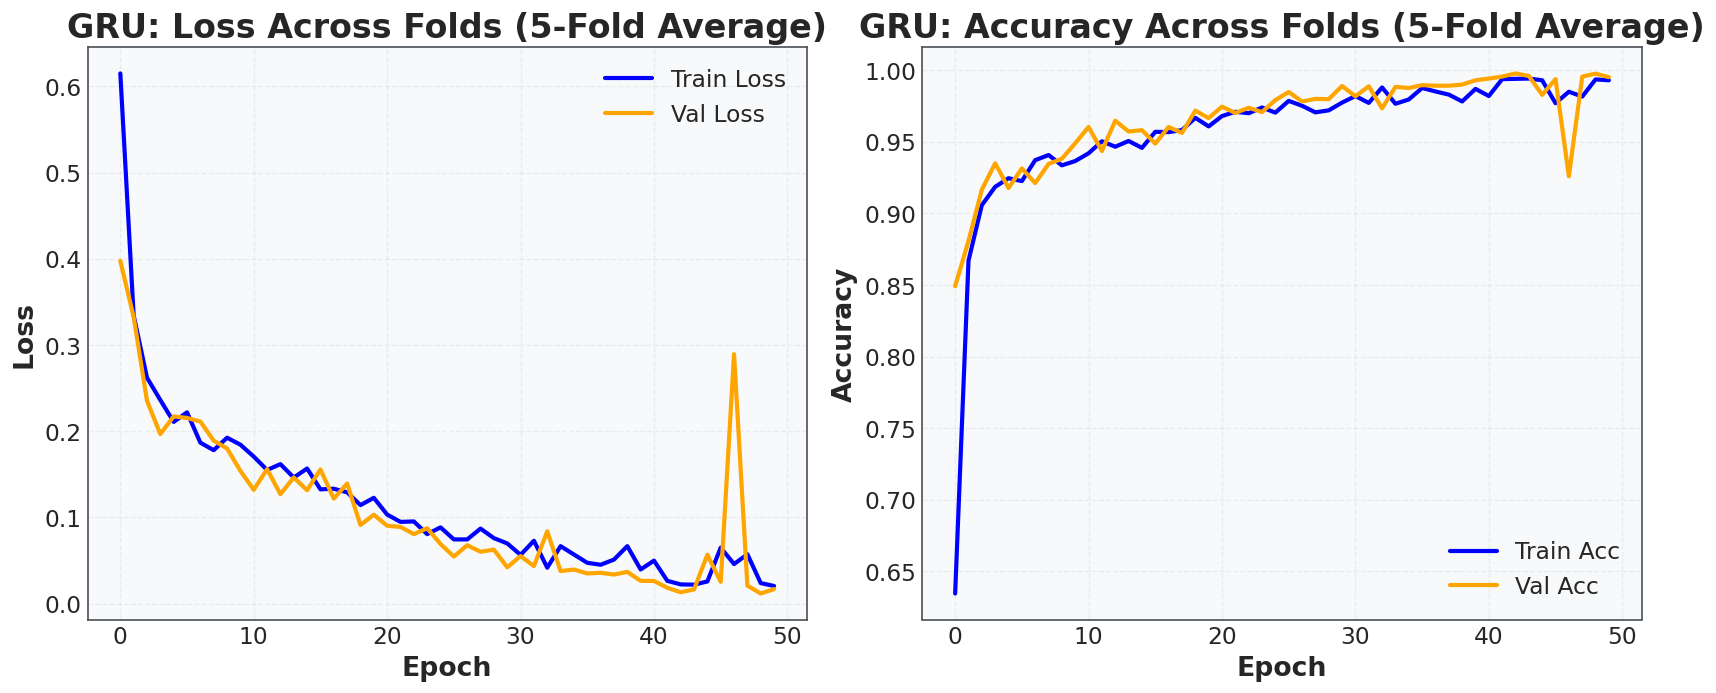

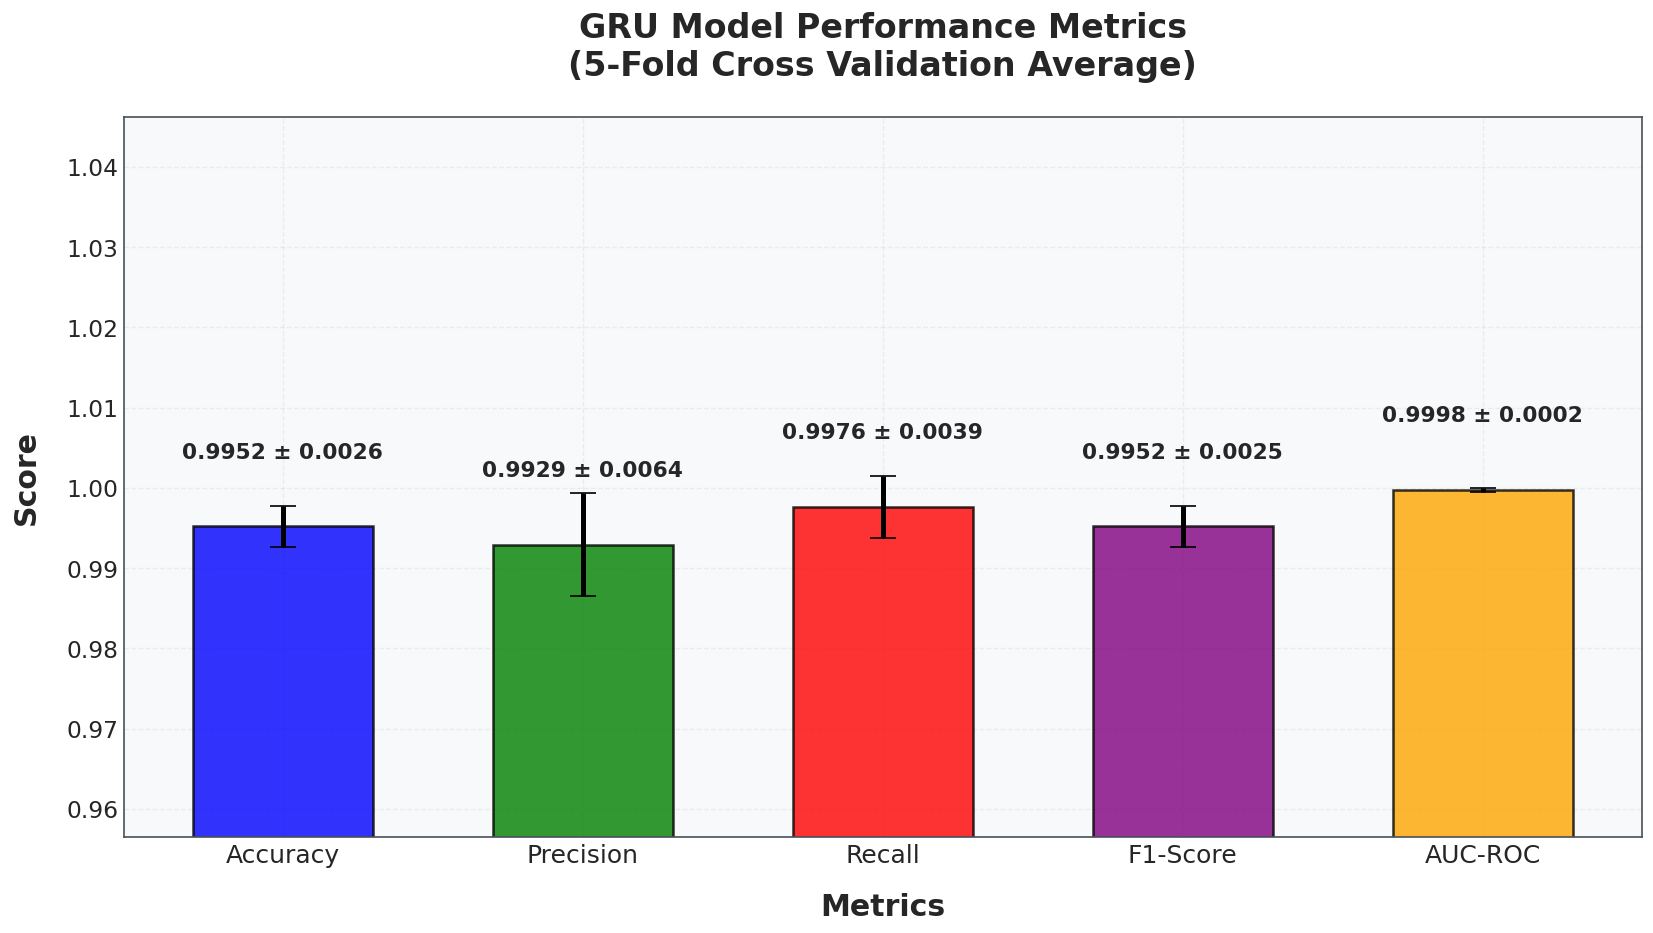

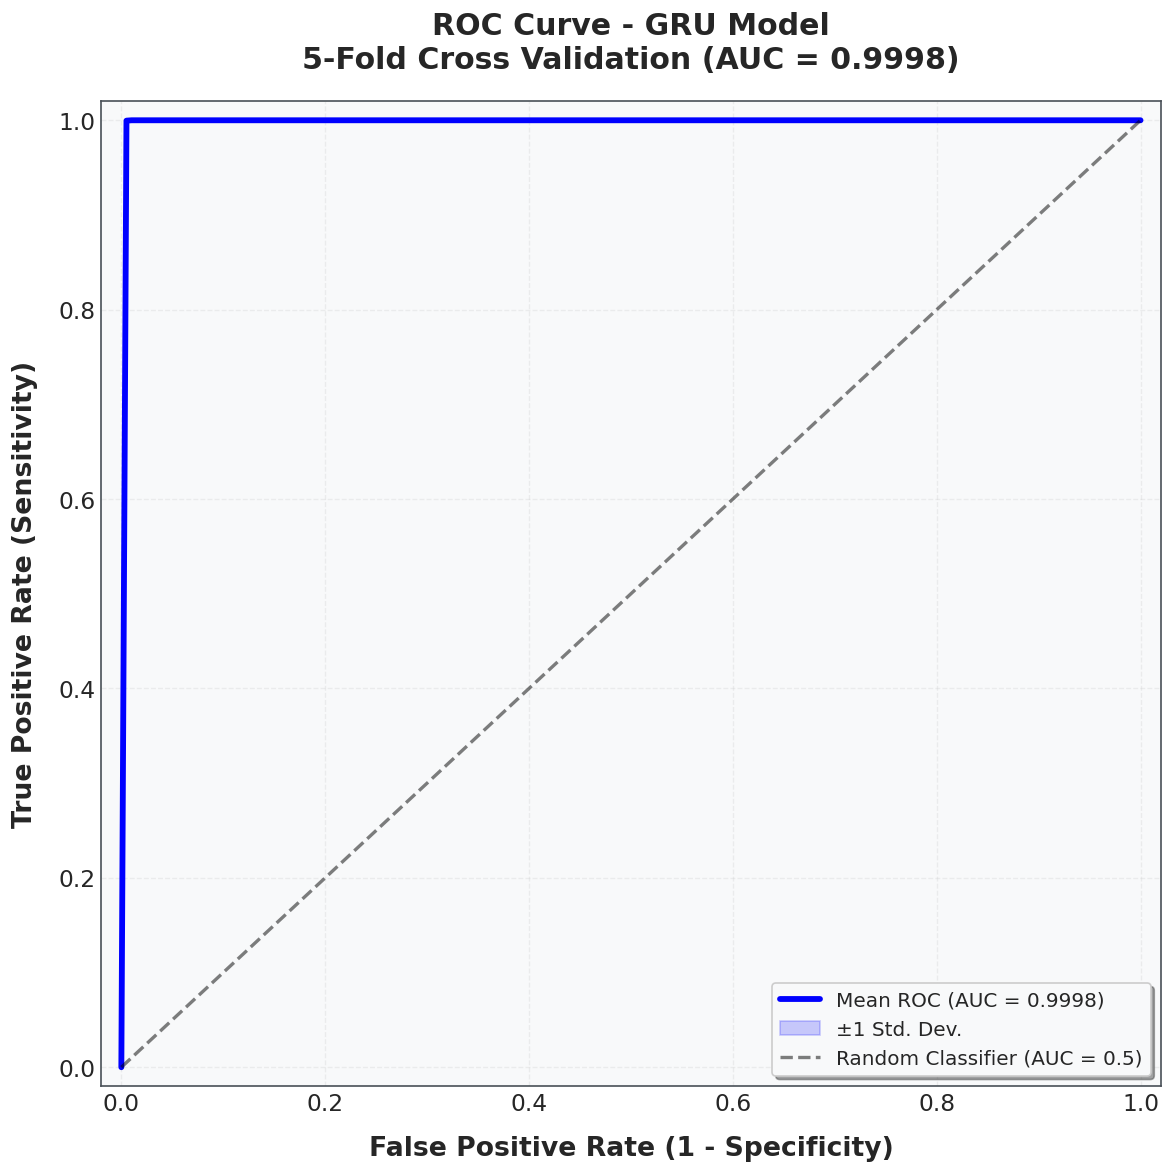

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7972\2241227751.py:450: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


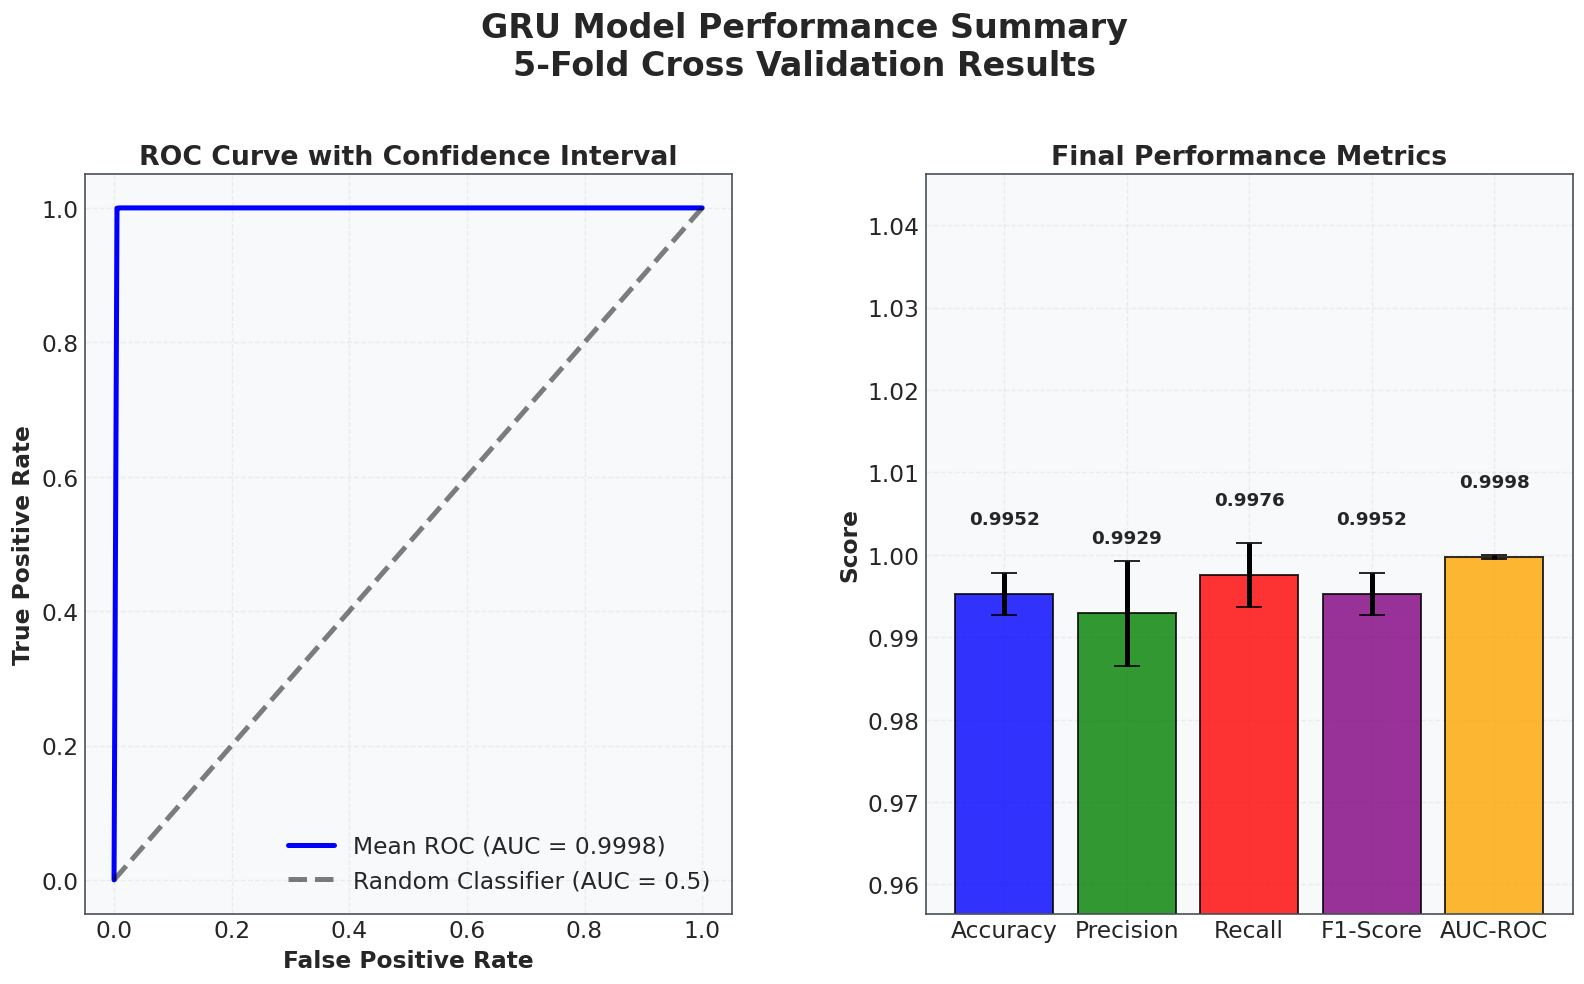

GRU MODEL PERFORMANCE SUMMARY (5-FOLD CROSS VALIDATION)

Final Metrics (Mean ± Std) across 5 folds:
--------------------------------------------------
Accuracy       : 0.9952 ± 0.0026
Precision      : 0.9929 ± 0.0064
Recall         : 0.9976 ± 0.0039
F1-Score       : 0.9952 ± 0.0025
AUC-ROC        : 0.9998 ± 0.0002
--------------------------------------------------

🌟 Excellent Performance! AUC = 0.9998

Saved figures:
Loss/Accuracy: GRU_Results\full\figures\GRU_Loss_Accuracy_5Fold.png
Final Metrics Bar: GRU_Results\full\figures\GRU_Final_Metrics_Bar_STD.png
Mean ROC No Markers: GRU_Results\full\figures\GRU_Mean_ROC_Curve_Beautiful_Blue_No_Markers.png
Dashboard: GRU_Results\full\figures\GRU_Performance_Dashboard.png


In [11]:
# ============================================================
# CELL 2
# Plot GRU Results from Saved Outputs
#
# Inputs from CELL 1:
#   GRU_Final_Metrics_Mean_STD.csv
#   GRU_Epoch_Metrics_All_Folds.csv
#   GRU_Runtime_Summary.csv
#   GRU_ROC_Data.npz
#
# Output:
#   High-quality figures saved in:
#   GRU_Results/{VARIANT_NAME}/figures/
# ============================================================


# =========================
# Imports
# =========================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path


# =========================
# Paths
# =========================

VARIANT_NAME = "full"

results_root = Path("GRU_Results") / VARIANT_NAME
figures_root = results_root / "figures"

figures_root.mkdir(parents=True, exist_ok=True)


# =========================
# Load Saved Outputs
# =========================

epoch_metrics_path = results_root / "GRU_Epoch_Metrics_All_Folds.csv"
final_summary_path = results_root / "GRU_Final_Metrics_Mean_STD.csv"
runtime_summary_path = results_root / "GRU_Runtime_Summary.csv"
roc_data_path = results_root / "GRU_ROC_Data.npz"

epoch_df = pd.read_csv(epoch_metrics_path)
final_summary_df = pd.read_csv(final_summary_path)
runtime_summary_df = pd.read_csv(runtime_summary_path)

roc_data = np.load(roc_data_path)

fpr_points = roc_data["fpr_points"]
mean_tpr = roc_data["mean_tpr"]
std_tpr = roc_data["std_tpr"]
mean_auc = float(roc_data["mean_auc"])

extra_metrics = final_summary_df["Metric"].tolist()
final_values = final_summary_df["Mean"].values
final_std = final_summary_df["Std"].values


# =========================
# Beautiful Plot Settings
# =========================

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

plt.rcParams.update({
    "font.size": 14,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "semibold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.framealpha": 0.9,
    "lines.linewidth": 3,
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.facecolor": "#F8F9FA",
    "axes.edgecolor": "#495057",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})


# =========================
# Function to draw ROC with straight lines
# Marker Removed
# =========================

def draw_straight_roc(fpr, tpr, label, color, ax, lw=1.8):

    idx = np.argsort(fpr)

    fpr = np.array(fpr)[idx]
    tpr = np.array(tpr)[idx]

    if fpr[0] != 0 or tpr[0] != 0:
        fpr = np.concatenate([[0], fpr])
        tpr = np.concatenate([[0], tpr])

    if fpr[-1] != 1 or tpr[-1] != 1:
        fpr = np.concatenate([fpr, [1]])
        tpr = np.concatenate([tpr, [1]])

    ax.plot(
        fpr,
        tpr,
        color=color,
        linewidth=lw,
        label=label
    )


# =========================
# Compute Loss / Accuracy Mean Curves
# =========================

grouped = epoch_df.groupby("epoch")

train_loss_mean = grouped["train_loss"].mean()
val_loss_mean = grouped["val_loss"].mean()

train_acc_mean = grouped["train_acc"].mean()
val_acc_mean = grouped["val_acc"].mean()


# =========================
# Figure 0: Train/Val Loss & Accuracy
# =========================

fig0 = plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(
    train_loss_mean.values,
    label="Train Loss",
    color="blue",
    linewidth=2.5
)
plt.plot(
    val_loss_mean.values,
    label="Val Loss",
    color="orange",
    linewidth=2.5
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU: Loss Across Folds (5-Fold Average)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(
    train_acc_mean.values,
    label="Train Acc",
    color="blue",
    linewidth=2.5
)
plt.plot(
    val_acc_mean.values,
    label="Val Acc",
    color="orange",
    linewidth=2.5
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU: Accuracy Across Folds (5-Fold Average)")
plt.legend()
plt.grid(True)

plt.tight_layout()

loss_acc_path = figures_root / "GRU_Loss_Accuracy_5Fold.png"
plt.savefig(loss_acc_path, dpi=300, bbox_inches="tight")
plt.show()


# =========================
# Figure 1: Final Metrics Bar Chart
# =========================

fig1 = plt.figure(figsize=(14, 8))

x_pos = np.arange(len(extra_metrics))

bars = plt.bar(
    x_pos,
    final_values,
    yerr=final_std,
    capsize=8,
    color=["blue", "green", "red", "purple", "orange"],
    edgecolor="black",
    linewidth=1.5,
    alpha=0.8,
    width=0.6
)

for bar, val, err in zip(bars, final_values, final_std):

    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.008,
        f"{val:.4f} ± {err:.4f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

plt.xlabel(
    "Metrics",
    fontsize=18,
    labelpad=15,
    fontweight="bold"
)

plt.ylabel(
    "Score",
    fontsize=18,
    labelpad=15,
    fontweight="bold"
)

plt.title(
    "GRU Model Performance Metrics\n(5-Fold Cross Validation Average)",
    fontsize=20,
    pad=25,
    fontweight="bold"
)

plt.xticks(
    x_pos,
    extra_metrics,
    fontsize=15
)

y_min = max(0.0, min(final_values) - max(final_std) - 0.03)
y_max = min(1.05, max(final_values) + max(final_std) + 0.04)

plt.ylim(y_min, y_max)
plt.grid(True, alpha=0.3, axis="y")

plt.tight_layout()

bar_path = figures_root / "GRU_Final_Metrics_Bar_STD.png"
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()


# =========================
# Figure 2: ROC Curve (Beautiful Blue - High Performance)
# =========================

fig2 = plt.figure(figsize=(10, 10))
ax = plt.subplot(111)

# Plot mean ROC curve in blue
draw_straight_roc(
    fpr_points,
    mean_tpr,
    label=f"Mean ROC (AUC = {mean_auc:.4f})",
    color="blue",
    ax=ax,
    lw=3.5
)

# Confidence interval
ax.fill_between(
    fpr_points,
    np.maximum(mean_tpr - std_tpr, 0),
    np.minimum(mean_tpr + std_tpr, 1),
    color="blue",
    alpha=0.2,
    label="±1 Std. Dev."
)

# Diagonal line
ax.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=2,
    alpha=0.5,
    label="Random Classifier (AUC = 0.5)"
)

# Customize plot
ax.set_xlabel(
    "False Positive Rate (1 - Specificity)",
    fontsize=16,
    labelpad=12,
    fontweight="bold"
)

ax.set_ylabel(
    "True Positive Rate (Sensitivity)",
    fontsize=16,
    labelpad=12,
    fontweight="bold"
)

ax.set_title(
    f"ROC Curve - GRU Model\n5-Fold Cross Validation (AUC = {mean_auc:.4f})",
    fontsize=18,
    pad=20,
    fontweight="bold"
)

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.grid(True, alpha=0.3)

ax.legend(
    loc="lower right",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=12
)

plt.tight_layout()

roc_path = figures_root / "GRU_Mean_ROC_Curve_Beautiful_Blue_No_Markers.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()


# =========================
# Figure 3: Combined Dashboard
# =========================

fig3 = plt.figure(figsize=(16, 8))

gs = fig3.add_gridspec(
    1,
    2,
    wspace=0.3
)

# ROC Curve (left)
ax1 = fig3.add_subplot(gs[0, 0])

draw_straight_roc(
    fpr_points,
    mean_tpr,
    label=f"Mean ROC (AUC = {mean_auc:.4f})",
    color="blue",
    ax=ax1,
    lw=3
)

ax1.fill_between(
    fpr_points,
    np.maximum(mean_tpr - std_tpr, 0),
    np.minimum(mean_tpr + std_tpr, 1),
    color="blue",
    alpha=0.2
)

ax1.plot(
    [0, 1],
    [0, 1],
    "k--",
    alpha=0.5,
    label="Random Classifier (AUC = 0.5)"
)

ax1.set_xlabel(
    "False Positive Rate",
    fontsize=14,
    fontweight="bold"
)

ax1.set_ylabel(
    "True Positive Rate",
    fontsize=14,
    fontweight="bold"
)

ax1.set_title(
    "ROC Curve with Confidence Interval",
    fontweight="bold",
    fontsize=16
)

ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)


# Final metrics (right)
ax2 = fig3.add_subplot(gs[0, 1])

bars = ax2.bar(
    extra_metrics,
    final_values,
    yerr=final_std,
    capsize=8,
    color=["blue", "green", "red", "purple", "orange"],
    alpha=0.8,
    edgecolor="black",
    linewidth=1.2
)

ax2.set_ylabel(
    "Score",
    fontweight="bold",
    fontsize=14
)

ax2.set_title(
    "Final Performance Metrics",
    fontweight="bold",
    fontsize=16
)

ax2.set_ylim(y_min, y_max)
ax2.grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars, final_values):

    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.008,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

fig3.suptitle(
    "GRU Model Performance Summary\n5-Fold Cross Validation Results",
    fontsize=20,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()

dashboard_path = figures_root / "GRU_Performance_Dashboard.png"
plt.savefig(dashboard_path, dpi=300, bbox_inches="tight")
plt.show()


# =========================
# Print Summary Statistics
# =========================

print("=" * 60)
print("GRU MODEL PERFORMANCE SUMMARY (5-FOLD CROSS VALIDATION)")
print("=" * 60)

print("\nFinal Metrics (Mean ± Std) across 5 folds:")
print("-" * 50)

for metric, mean_value, std_value in zip(
    extra_metrics,
    final_values,
    final_std
):

    print(
        f"{metric:15s}: {mean_value:.4f} ± {std_value:.4f}"
    )

print("-" * 50)
print(f"\n🌟 Excellent Performance! AUC = {mean_auc:.4f}")
print("=" * 60)

print("\nSaved figures:")
print(f"Loss/Accuracy: {loss_acc_path}")
print(f"Final Metrics Bar: {bar_path}")
print(f"Mean ROC No Markers: {roc_path}")
print(f"Dashboard: {dashboard_path}")

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

feature_root = Path("HockeyFeatures")
VARIANT_NAME = "full"

results_root = Path("DENSE_Results") / VARIANT_NAME
results_root.mkdir(parents=True, exist_ok=True)

classes = ["Fight", "NoFight"]
folds = 5

batch_size = 16
epochs = 30
feature_dim = 512

# =========================
# SAFE LOADER
# =========================
def collect_files(root, fold, split, cls):
    candidates = [
        root / VARIANT_NAME / f"fold_{fold}" / split / cls,
        root / f"fold_{fold}" / split / cls,
        root / split / cls,
        root / VARIANT_NAME / split / cls
    ]

    for p in candidates:
        if p.exists():
            files = list(p.glob("*.npy"))
            if len(files) > 0:
                return sorted(files)
    return []

# =========================
class DatasetCls(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        x = np.load(self.files[i])
        return torch.tensor(x, dtype=torch.float32), torch.tensor(self.labels[i])

def collate(batch):
    x, y = zip(*batch)
    x = nn.utils.rnn.pad_sequence(x, batch_first=True)
    return x, torch.stack(y)

# =========================
# DENSE MODEL
# =========================
class Dense(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = x.mean(dim=1)
        return self.net(x)

# =========================
epoch_rows = []

for fold in range(1, folds + 1):

    print(f"\n===== FOLD {fold} =====")

    train_files, val_files = [], []
    train_labels, val_labels = [], []

    for i, cls in enumerate(classes):

        tr = collect_files(feature_root, fold, "train", cls)
        va = collect_files(feature_root, fold, "val", cls)

        train_files += tr
        val_files += va

        train_labels += [i] * len(tr)
        val_labels += [i] * len(va)

    print("Train:", len(train_files), "Val:", len(val_files))

    if len(train_files) == 0 or len(val_files) == 0:
        print("SKIP FOLD")
        continue

    train_ds = DatasetCls(train_files, train_labels)
    val_ds = DatasetCls(val_files, val_labels)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate)

    model = Dense().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):

        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()

        model.eval()
        p_all, y_all = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                p = torch.softmax(model(x), dim=1)[:, 1]

                p_all.extend(p.cpu().numpy())
                y_all.extend(y.cpu().numpy())

        auc = roc_auc_score(y_all, p_all)

        epoch_rows.append({
            "fold": fold,
            "epoch": epoch,
            "val_auc": auc
        })

        print(f"Epoch {epoch} | AUC={auc:.4f}")

pd.DataFrame(epoch_rows).to_csv(results_root / "DENSE_Epoch.csv", index=False)

print("\nDENSE COMPLETED")


===== FOLD 1 =====
Train: 0 Val: 0
SKIP FOLD

===== FOLD 2 =====
Train: 0 Val: 0
SKIP FOLD

===== FOLD 3 =====
Train: 0 Val: 0
SKIP FOLD

===== FOLD 4 =====
Train: 0 Val: 0
SKIP FOLD

===== FOLD 5 =====
Train: 0 Val: 0
SKIP FOLD

DENSE COMPLETED
